# Skenario 2 — Data Balancing & Augmentation
**Tujuan:** Membandingkan 4 strategi augmentasi data  
- **Branch A:** Raw (tanpa augmentasi)
- **Branch B:** Random Oversampling
- **Branch C:** Back-translation (ID→EN→ID)
- **Branch D:** Synonym Replacement

**Task:** Klasifikasi Emosi (5 kelas) dan Sentimen (3 kelas)

---
**Strategi hemat RAM:** Setiap kombinasi (task × branch × model) dilatih satu per satu, hasilnya langsung di-save ke `results_s2.json`.

**🏆 Best model:** Model + tokenizer terbaik per task (across semua branch) di-save ke `/kaggle/working/best_model_s2_{task}/`

## 0. Install & Import

In [1]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip("transformers[torch]", "datasets", "accelerate", "scikit-learn",
    "imbalanced-learn", "deep-translator", "nltk", "seaborn", "matplotlib",
    "pandas", "numpy", "torch")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import os, re, json, warnings, random, time, gc
from copy import deepcopy
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import nltk

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from deep_translator import GoogleTranslator
from nltk.corpus import wordnet

from tqdm import tqdm

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


## 1. Load & Preprocessing Dataset

In [3]:
DATA_PATH = "/kaggle/input/datasets/carameyyow/secondary/PRDECT-ID Dataset_clean.csv"

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

print("Shape :", df.shape)
print("Kolom :", df.columns.tolist())
display(df.head(3))

Shape : (5400, 16)
Kolom : ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion', 'Location_grouped', 'review_text', 'review_char_len', 'review_word_len', 'review_tokens']


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion,Location_grouped,review_text,review_char_len,review_word_len,review_tokens
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy,Jakarta Utara,Alhamdulillah berfungsi dengan baik. Packaging...,100,14,"['alhamdulillah', 'berfungsi', 'baik', 'packag..."
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy,Kota Tangerang Selatan,"barang bagus dan respon cepat, harga bersaing ...",61,10,"['barang', 'bagus', 'respon', 'cepat', 'harga'..."
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy,Jakarta Barat,"barang bagus, berfungsi dengan baik, seler ram...",66,9,"['barang', 'bagus', 'berfungsi', 'baik', 'sele..."


In [4]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["Customer Review"].apply(clean_text)

le_sent = LabelEncoder()
le_emot = LabelEncoder()
df["label_sentiment"] = le_sent.fit_transform(df["Sentiment"])
df["label_emotion"]   = le_emot.fit_transform(df["Emotion"])

print("Label Sentimen :", dict(zip(le_sent.classes_, le_sent.transform(le_sent.classes_))))
print("Label Emosi    :", dict(zip(le_emot.classes_, le_emot.transform(le_emot.classes_))))
display(df[["Customer Review","text_clean","Sentiment","label_sentiment","Emotion","label_emotion"]].head(4))

Label Sentimen : {'Negative': np.int64(0), 'Positive': np.int64(1)}
Label Emosi    : {'Anger': np.int64(0), 'Fear': np.int64(1), 'Happy': np.int64(2), 'Love': np.int64(3), 'Sadness': np.int64(4)}


,Customer Review,text_clean,Sentiment,label_sentiment,Emotion,label_emotion
0,Alhamdulillah berfungsi dengan baik. Packaging...,alhamdulillah berfungsi dengan baik packaging ...,Positive,1,Happy,2
1,"barang bagus dan respon cepat, harga bersaing ...",barang bagus dan respon cepat harga bersaing d...,Positive,1,Happy,2
2,"barang bagus, berfungsi dengan baik, seler ram...",barang bagus berfungsi dengan baik seler ramah...,Positive,1,Happy,2
3,bagus sesuai harapan penjual nya juga ramah. t...,bagus sesuai harapan penjual nya juga ramah tr...,Positive,1,Happy,2


## 2. Helper Functions

In [5]:
# salah satu aja
TASKS = {
    "Emotion":   ("text_clean", "label_emotion",   le_emot.classes_),
    "Sentiment": ("text_clean", "label_sentiment", le_sent.classes_),
}

def make_splits(texts, labels, test_size=0.2, val_size=0.1):
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=test_size, random_state=SEED, stratify=labels)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size/(1-test_size), random_state=SEED, stratify=y_train)
    return X_train, X_val, X_test, y_train, y_val, y_test

def build_hf_dataset(texts, labels, tokenizer, max_len=128):
    enc = tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    labels = np.asarray(labels, dtype=np.int64)

    return HFDataset.from_dict({
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels": labels,
    })

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }


def train_and_evaluate(model_name, train_ds, val_ds, test_texts, test_labels,
                       tokenizer, num_labels, label_names,
                       output_dir="./tmp_model",
                       num_epochs=3, batch_size=8, lr=2e-5,
                       weight_decay=0.01, dropout=None,
                       warmup_ratio=0.1, max_len=128,
                       grad_accum=2):
    import time
    current_batch_size = batch_size
    while True:
        try:
            # Retry loading model dengan network resilience
            for attempt in range(3):
                try:
                    model = AutoModelForSequenceClassification.from_pretrained(
                        model_name, num_labels=num_labels, ignore_mismatched_sizes=True)
                    break
                except Exception as e:
                    if attempt == 2:
                        raise e
                    print(f"  ⚠️ Gagal download model {model_name}, mencoba lagi ({attempt+2}/3) dalam 5 detik... (Error: {e})")
                    time.sleep(5)

            if dropout is not None and hasattr(model.config, "hidden_dropout_prob"):
                model.config.hidden_dropout_prob = dropout
                model.config.attention_probs_dropout_prob = dropout

            args = TrainingArguments(
                output_dir=output_dir,
                num_train_epochs=num_epochs,
                per_device_train_batch_size=current_batch_size,
                per_device_eval_batch_size=current_batch_size,
                gradient_accumulation_steps=grad_accum,
                learning_rate=lr,
                weight_decay=weight_decay,
                warmup_ratio=warmup_ratio,
                eval_strategy="epoch",
                save_strategy="epoch",
                save_total_limit=1,
                save_only_model=True,
                load_best_model_at_end=True,
                metric_for_best_model="f1_macro",
                logging_steps=50,
                fp16=(DEVICE == "cuda"),
                report_to="none",
                seed=SEED,
            )

            trainer = Trainer(
                model=model,
                args=args,
                train_dataset=train_ds,
                eval_dataset=val_ds,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
            )

            t0 = time.time()
            trainer.train()
            elapsed = time.time() - t0
            break
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"  ⚠️ [OOM] CUDA out of memory dengan batch_size={current_batch_size}.")
                if 'trainer' in locals():
                    del trainer
                if 'model' in locals():
                    del model
                free_memory()
                current_batch_size = current_batch_size // 2

                grad_accum = grad_accum * 2

                if current_batch_size < 2:
                    print("  ❌ [OOM] Batch size sudah minimum (< 2). Gagal melatih model ini.")
                    raise e
                print(f"  🔄 Mencoba ulang dengan batch_size={current_batch_size} dan grad_accum={grad_accum}...")
            else:
                raise e

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer, max_len)
    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    metrics = {
        "accuracy":    round(accuracy_score(test_labels, preds), 4),
        "f1_macro":    round(f1_score(test_labels, preds, average="macro"), 4),
        "f1_weighted": round(f1_score(test_labels, preds, average="weighted"), 4),
        "train_time_s": round(elapsed, 1),
    }
    report = classification_report(test_labels, preds, target_names=label_names)
    return trainer, metrics, report, preds


def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def save_best_model(trainer, tokenizer, task_name, model_alias, model_name,
                    branch_name, metrics, label_names, skenario="2"):
    """Simpan model + tokenizer + metadata ke folder best_model_s{skenario}_{task}."""
    best_dir = f"best_model_s{skenario}_{task_name}"
    os.makedirs(best_dir, exist_ok=True)
    trainer.save_model(best_dir)
    tokenizer.save_pretrained(best_dir)
    meta = {
        "skenario": skenario,
        "task": task_name,
        "model_alias": model_alias,
        "model_name": model_name,
        "branch": branch_name,
        "label_names": list(label_names),
        "metrics": metrics,
    }
    with open(f"{best_dir}/best_model_info.json", "w") as f:
        json.dump(meta, f, indent=2)
    print(f"  🏆 [BEST MODEL] {model_alias} @ {branch_name} (f1_macro={metrics['f1_macro']:.4f}) → {best_dir}")

## 3. Augmentation Functions

In [6]:
# ── Branch B: Random Oversampling ─────────────────────────────────────
def oversample_data(texts, labels):
    """Duplikasi sampel kelas minoritas."""
    ros = RandomOverSampler(random_state=SEED)
    idx = np.arange(len(texts)).reshape(-1, 1)
    idx_res, labels_res = ros.fit_resample(idx, labels)
    texts_res = texts[idx_res.flatten()]
    return texts_res, labels_res


# ── Branch C: Back-translation ID → EN → ID ───────────────────────────
def back_translate(text: str) -> str:
    try:
        en = GoogleTranslator(source="id", target="en").translate(text[:500])
        id_ = GoogleTranslator(source="en", target="id").translate(en)
        time.sleep(0.5)
        return id_ if id_ else text
    except Exception as e:
        print(f"    [Translate Error]: {e}")
        return text

def augment_backtranslation(
    texts,
    labels,
    min_count=None,
    save_path="branch_c_backup.csv"
):
    # ==========================
    # LOAD CACHE
    # ==========================
    if os.path.exists(save_path):
        print(f"  ✅ [CACHE] Load {save_path}")

        df_backup = pd.read_csv(save_path)

        return (
            df_backup["text"].values,
            df_backup["label"].astype(int).values
        )

    # ==========================
    # Hitung target jumlah data
    # ==========================
    if min_count is None:
        cnt = Counter(labels)
        min_count = max(cnt.values())

    aug_texts = list(texts)
    aug_labels = list(labels)

    cnt = Counter(labels)

    for cls, count in cnt.items():

        need = min_count - count

        if need <= 0:
            continue

        cls_idx = np.where(labels == cls)[0]

        sample_idx = np.random.choice(
            cls_idx,
            size=need,
            replace=(need > len(cls_idx))
        )

        print(f"  Back-translating {need} samples for class {cls}...")

        for i in tqdm(sample_idx, desc=f"Translate {cls}"):

            aug_texts.append(back_translate(texts[i]))
            aug_labels.append(int(cls))

        # ==========================
        # AUTO SAVE
        # ==========================
        pd.DataFrame({
            "text": aug_texts,
            "label": aug_labels
        }).to_csv(save_path, index=False)

        print(f"  💾 Saved → {save_path}")

    return (
        np.array(aug_texts),
        np.array(aug_labels, dtype=np.int64)
    )

# ── Branch D: Synonym Replacement ─────────────────────────────────────
def get_synonym(word: str) -> str:
    syns = wordnet.synsets(word, lang='ind')
    for syn in syns:
        for lemma in syn.lemmas(lang='ind'):
            if lemma.name() != word:
                return lemma.name().replace("_", " ")
    return word

def synonym_replace(text: str, n: int = 2) -> str:
    words = text.split()
    if len(words) < 3:
        return text
    indices = random.sample(range(len(words)), min(n, len(words)))
    for i in indices:
        words[i] = get_synonym(words[i])
    return " ".join(words)

def augment_synonym(texts, labels, min_count=None):
    if min_count is None:
        cnt = Counter(labels)
        min_count = max(cnt.values())

    aug_texts, aug_labels = list(texts), list(labels)
    cnt = Counter(labels)

    for cls, count in cnt.items():
        need = min_count - count
        if need <= 0:
            continue
        cls_idx = np.where(labels == cls)[0]
        sample_idx = np.random.choice(cls_idx, size=need, replace=(need > len(cls_idx)))
        for i in sample_idx:
            aug_texts.append(synonym_replace(texts[i]))
            aug_labels.append(cls)

    return np.array(aug_texts), np.array(aug_labels)

---
# SKENARIO 2 — Training Loop

Setiap model × branch × task dilatih satu per satu → hasil di-save ke JSON → **best model per task disimpan** → memory dibebaskan.

In [7]:
FAST_MODE_S2   = False   # True untuk quick test
SKIP_BACKTRANS = False    # True untuk skip back-translation (lambat)
NUM_EPOCHS_S2  = 3
BATCH_SIZE_S2  = 8
LR_S2 = 2e-5

S2_MODELS = {
    #"DistilBERT": "distilbert-base-multilingual-cased",
    "IndoBERT":  "indobenchmark/indobert-base-p1"
}

RESULTS_FILE = "/content/results_s2.json"

# Load hasil yang sudah ada (untuk resume)
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        S2_RESULTS = json.load(f)
    print(f"Resume dari: {list(S2_RESULTS.keys())}")
else:
    S2_RESULTS = {}
    print("Mulai dari awal.")

# Tracker best model per task
BEST_MODEL_TRACKER = {}

Mulai dari awal.


In [8]:
# Siapkan semua augmented data terlebih dahulu (tidak perlu GPU)
S2_BRANCHES = {}
S2_SPLITS   = {}

for task_name, (text_col, label_col, label_names) in TASKS.items():
    print(f"\n=================== PREPARING DATA FOR TASK: {task_name} ===================")

    texts_all  = df[text_col].values
    labels_all = df[label_col].values

    if FAST_MODE_S2:
        idx = np.random.choice(
            len(texts_all),
            size=int(len(texts_all) * 0.3),
            replace=False
        )
        texts_all  = texts_all[idx]
        labels_all = labels_all[idx]

    X_train_raw, X_val, X_test, y_train_raw, y_val, y_test = make_splits(
        texts_all,
        labels_all
    )

    S2_SPLITS[task_name] = (
        X_train_raw,
        X_val,
        X_test,
        y_train_raw,
        y_val,
        y_test
    )

    print(
        f"[{task_name}] Base split → "
        f"Train: {len(X_train_raw)}, "
        f"Val: {len(X_val)}, "
        f"Test: {len(X_test)}"
    )

    branches = {
        "A_Raw": (
            X_train_raw.copy(),
            y_train_raw.copy()
        )
    }

    # ==========================
    # Branch B
    # ==========================
    print(f"[{task_name}] [Branch B] Oversampling...")

    X_B, y_B = oversample_data(
        X_train_raw,
        y_train_raw
    )

    branches["B_Oversample"] = (X_B, y_B)

    print(f"  → Setelah oversample: {len(X_B)}")

    # ==========================
    # Branch C
    # ==========================
    if not SKIP_BACKTRANS:

        print(f"[{task_name}] [Branch C] Back-translation...")

        cache_file = f"branch_c_backup_{task_name}.csv"

        X_C, y_C = augment_backtranslation(
            X_train_raw,
            y_train_raw,
            save_path=cache_file
        )

        # VALIDASI LABEL
        assert len(X_C) == len(y_C), \
            "Jumlah text dan label tidak sama."

        assert np.max(y_C) < len(label_names), \
            f"Label tidak valid! max label={np.max(y_C)}, num_labels={len(label_names)}"

        print(f"  Cache : {cache_file}")
        print(f"  Label : {np.unique(y_C)}")

        branches["C_BackTrans"] = (
            X_C,
            y_C
        )

        print(f"  → Setelah back-trans: {len(X_C)}")

    else:
        print(f"[{task_name}] [Branch C] Skipped (SKIP_BACKTRANS=True)")

    # ==========================
    # Branch D
    # ==========================
    print(f"[{task_name}] [Branch D] Synonym replacement...")

    X_D, y_D = augment_synonym(
        X_train_raw,
        y_train_raw
    )

    branches["D_Synonym"] = (
        X_D,
        y_D
    )

    print(f"  → Setelah synonym aug: {len(X_D)}")

    S2_BRANCHES[task_name] = branches

print("\nSemua data augmentation selesai!")


=================== PREPARING DATA FOR TASK: Emotion ===================
[Emotion] Base split → Train: 3780, Val: 540, Test: 1080
[Emotion] [Branch B] Oversampling...
  → Setelah oversample: 6195
[Emotion] [Branch C] Back-translation...
  Back-translating 397 samples for class 4...


Translate 4: 100%|██████████| 397/397 [11:43<00:00,  1.77s/it]


  💾 Saved → branch_c_backup_Emotion.csv
  Back-translating 673 samples for class 3...


Translate 3: 100%|██████████| 673/673 [14:11<00:00,  1.27s/it]


  💾 Saved → branch_c_backup_Emotion.csv
  Back-translating 750 samples for class 0...


...

    [Translate Error]: seller lumayan responsif kualitas brg sesuai harga so so lah dicek di browser ps nya kebaca mb tp kalo udah dipake save di game cuman kebaca mb ga semua game bisa ngebaca mc nya sayangnya game game yg top yg ga mau ngebaca mc nya kaya god of war --> No translation was found using the current translator. Try another translator?


Translate 1: 100%|██████████| 595/595 [19:03<00:00,  1.92s/it]


  💾 Saved → branch_c_backup_Emotion.csv
  Cache : branch_c_backup_Emotion.csv
  Label : [0 1 2 3 4]
  → Setelah back-trans: 6195
[Emotion] [Branch D] Synonym replacement...
  → Setelah synonym aug: 6195

=================== PREPARING DATA FOR TASK: Sentiment ===================
[Sentiment] Base split → Train: 3780, Val: 540, Test: 1080
[Sentiment] [Branch B] Oversampling...
  → Setelah oversample: 3950
[Sentiment] [Branch C] Back-translation...
  Back-translating 170 samples for class 1...


Translate 1: 100%|██████████| 170/170 [04:50<00:00,  1.71s/it]

  💾 Saved → branch_c_backup_Sentiment.csv
  Cache : branch_c_backup_Sentiment.csv
  Label : [0 1]
  → Setelah back-trans: 3950
[Sentiment] [Branch D] Synonym replacement...
  → Setelah synonym aug: 3950

Semua data augmentation selesai!


In [9]:
import pandas as pd
import numpy as np

df_bt = pd.read_csv("branch_c_backup_Sentiment.csv")

print(df_bt.head())
print(df_bt["label"].value_counts())
print(df_bt["label"].unique())
print(df_bt["label"].dtype)

                                                text  label
0                             pengiriman sangat lama      0
1                                bagus mantab jernih      1
2  pegawai nya kurang fokus nih pengiriman kurang...      0
3  murah dan mudah digunakan setidaknya nya berma...      1
4  warnanya cantik tpi syg kurang tajem kupas kul...      0
label
0    1975
1    1975
Name: count, dtype: int64
[0 1]
int64


In [10]:
# Training loop — model dilatih satu per satu
for task_name, (text_col, label_col, label_names) in TASKS.items():
    print(f"\n=================== TRAINING SKENARIO 2 FOR TASK: {task_name} ===================")

    num_labels = len(label_names)
    X_train_raw, X_val, X_test, y_train_raw, y_val, y_test = S2_SPLITS[task_name]
    branches = S2_BRANCHES[task_name]

    for branch_name, (X_train, y_train) in branches.items():
        for model_alias, model_name in S2_MODELS.items():
            result_key = f"{task_name}|{branch_name}|{model_alias}"

            # Skip jika sudah ada — tetap update tracker
            if task_name in S2_RESULTS:
                if branch_name in S2_RESULTS[task_name]:
                    if model_alias in S2_RESULTS[task_name][branch_name]:
                        print(f"  [SKIP] {result_key} sudah ada.")
                        existing_f1 = S2_RESULTS[task_name][branch_name][model_alias]["metrics"]["f1_macro"]
                        if task_name not in BEST_MODEL_TRACKER or existing_f1 > BEST_MODEL_TRACKER[task_name]["f1_macro"]:
                            BEST_MODEL_TRACKER[task_name] = {"f1_macro": existing_f1, "model_alias": model_alias,
                                                             "branch": branch_name, "model_name": model_name}
                        continue

            print(f"\n>>> Task: {task_name} | {branch_name} — {model_alias}")

            try:
                # Retry loading tokenizer dengan network resilience
                import time
                for attempt in range(3):
                    try:
                        tokenizer = AutoTokenizer.from_pretrained(model_name)
                        break
                    except Exception as e:
                        if attempt == 2:
                            raise e
                        print(f"  ⚠️ Gagal download tokenizer {model_name}, mencoba lagi ({attempt+2}/3) dalam 5 detik... (Error: {e})")
                        time.sleep(5)

                print("=" * 50)
                print(task_name, branch_name)
                print("X_train:", len(X_train))
                print("y_train:", len(y_train))
                print("dtype:", np.array(y_train).dtype)
                print("unique:", np.unique(y_train))
                print("num_labels:", num_labels)
                print("max label:", np.max(y_train))
                print("min label:", np.min(y_train))
                print("=" * 50)

                train_ds = build_hf_dataset(X_train, y_train, tokenizer)
                val_ds   = build_hf_dataset(X_val,   y_val,   tokenizer)

                output_dir = f"/content/s2_{task_name}_{branch_name}_{model_alias}"

                trainer, metrics, report, preds = train_and_evaluate(
                    model_name, train_ds, val_ds, X_test, y_test,
                    tokenizer, num_labels, label_names,
                    output_dir=output_dir,
                    num_epochs=NUM_EPOCHS_S2,
                    batch_size=BATCH_SIZE_S2,
                    lr=LR_S2,
                )

                print(f"  F1 Macro: {metrics['f1_macro']} | Accuracy: {metrics['accuracy']}")

                # Simpan hasil
                if task_name not in S2_RESULTS:
                    S2_RESULTS[task_name] = {}
                if branch_name not in S2_RESULTS[task_name]:
                    S2_RESULTS[task_name][branch_name] = {}

                S2_RESULTS[task_name][branch_name][model_alias] = {
                    "metrics": metrics,
                    "report":  report,
                }

                # ── Cek & simpan best model ──────────────────────────────────
                current_f1 = metrics["f1_macro"]
                if task_name not in BEST_MODEL_TRACKER or current_f1 > BEST_MODEL_TRACKER[task_name]["f1_macro"]:
                    BEST_MODEL_TRACKER[task_name] = {
                        "f1_macro": current_f1,
                        "model_alias": model_alias,
                        "branch": branch_name,
                        "model_name": model_name,
                    }
                    save_best_model(trainer, tokenizer, task_name, model_alias, model_name,
                                    branch_name, metrics, label_names, skenario="2")
                else:
                    print(f"  (bukan best: {current_f1:.4f} < {BEST_MODEL_TRACKER[task_name]['f1_macro']:.4f})")

                with open(RESULTS_FILE, "w") as f:
                    json.dump(S2_RESULTS, f, indent=2)
                print(f"  [SAVED] → {RESULTS_FILE}")

                # Bebaskan memori
                del trainer, tokenizer, train_ds, val_ds
                free_memory()

                # Hapus folder output tiap iterasi biar ngga OOM
                import shutil
                if os.path.exists(output_dir):
                    shutil.rmtree(output_dir, ignore_errors=True)

            except Exception as e:
                print(f"  [ERROR] {result_key}: {e}")
                free_memory()
                import shutil
                if 'output_dir' in locals() and os.path.exists(output_dir):
                    shutil.rmtree(output_dir, ignore_errors=True)

print("\n✅ Skenario 2 selesai!")
print("\n🏆 Best Models per Task:")
for task, info in BEST_MODEL_TRACKER.items():
    print(f"  {task}: {info['model_alias']} @ {info['branch']} (f1_macro={info['f1_macro']:.4f}) → /content/best_model_s2_{task}/")


=================== TRAINING SKENARIO 2 FOR TASK: Emotion ===================

>>> Task: Emotion | A_Raw — IndoBERT


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  F1 Macro: 0.9805 | Accuracy: 0.9806
  (bukan best: 0.9805 < 0.9833)
  [SAVED] → /content/results_s2.json

✅ Skenario 2 selesai!

🏆 Best Models per Task:
  Emotion: IndoBERT @ A_Raw (f1_macro=0.6618) → /content/best_model_s2_Emotion/
  Sentiment: IndoBERT @ A_Raw (f1_macro=0.9833) → /content/best_model_s2_Sentiment/


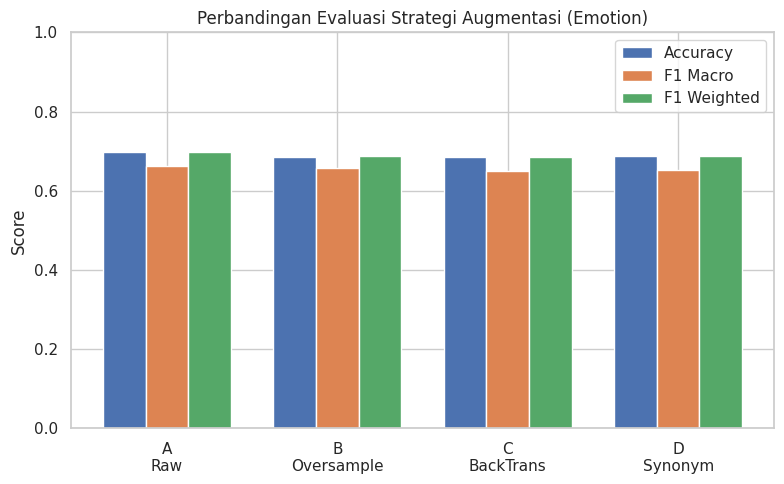

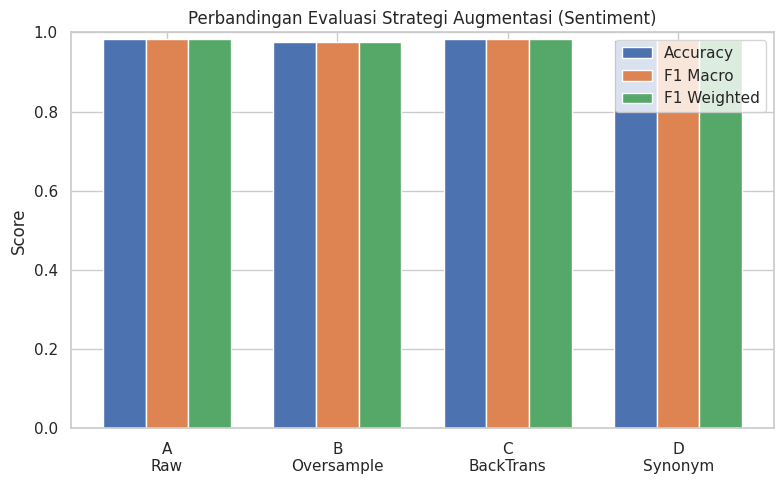

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# PERBANDINGAN HASIL AUGMENTASI
# ==========================

for task_name in S2_RESULTS.keys():

    rows = []

    for branch_name in S2_RESULTS[task_name]:
        for model_alias in S2_RESULTS[task_name][branch_name]:

            m = S2_RESULTS[task_name][branch_name][model_alias]["metrics"]

            rows.append({
                "Branch": branch_name.replace("_", "\n"),
                "Accuracy": m["accuracy"],
                "F1 Macro": m["f1_macro"],
                "F1 Weighted": m["f1_weighted"]
            })

    df_plot = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(8,5))

    x = range(len(df_plot))
    w = 0.25

    ax.bar([i-w for i in x], df_plot["Accuracy"], width=w, label="Accuracy")
    ax.bar(x, df_plot["F1 Macro"], width=w, label="F1 Macro")
    ax.bar([i+w for i in x], df_plot["F1 Weighted"], width=w, label="F1 Weighted")

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["Branch"])

    ax.set_ylim(0,1)
    ax.set_ylabel("Score")
    ax.set_title(f"Perbandingan Evaluasi Strategi Augmentasi ({task_name})")
    ax.legend()

    plt.tight_layout()
    plt.show()


Membuat Word Cloud berdasarkan hasil PREDIKSI Best Model Skenario 2...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

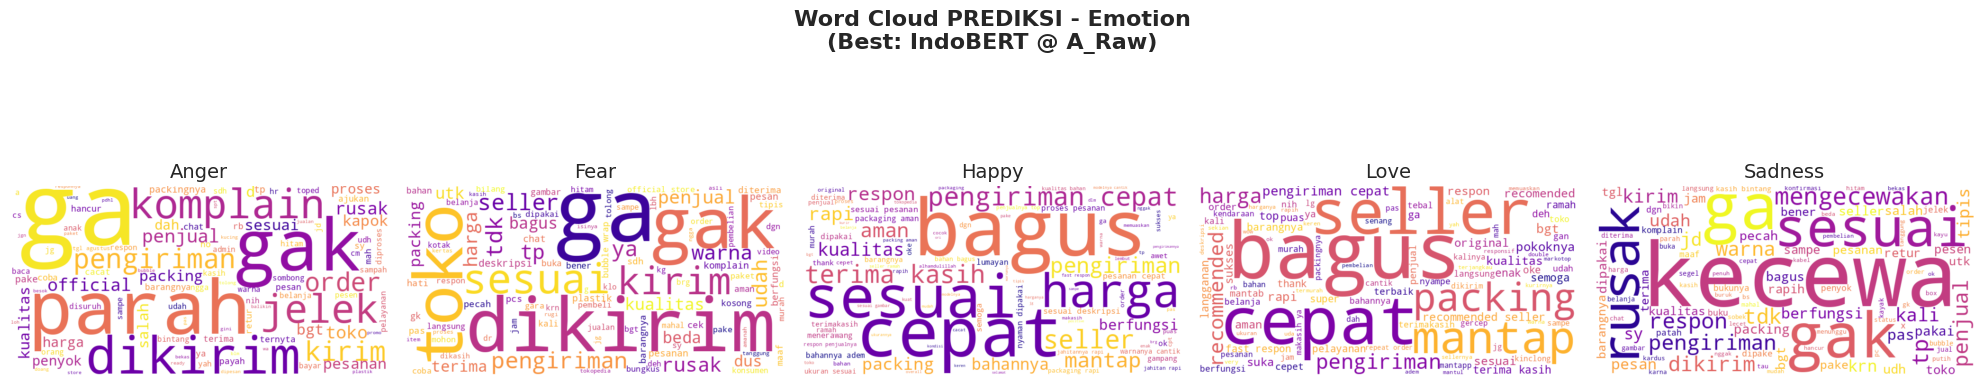

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

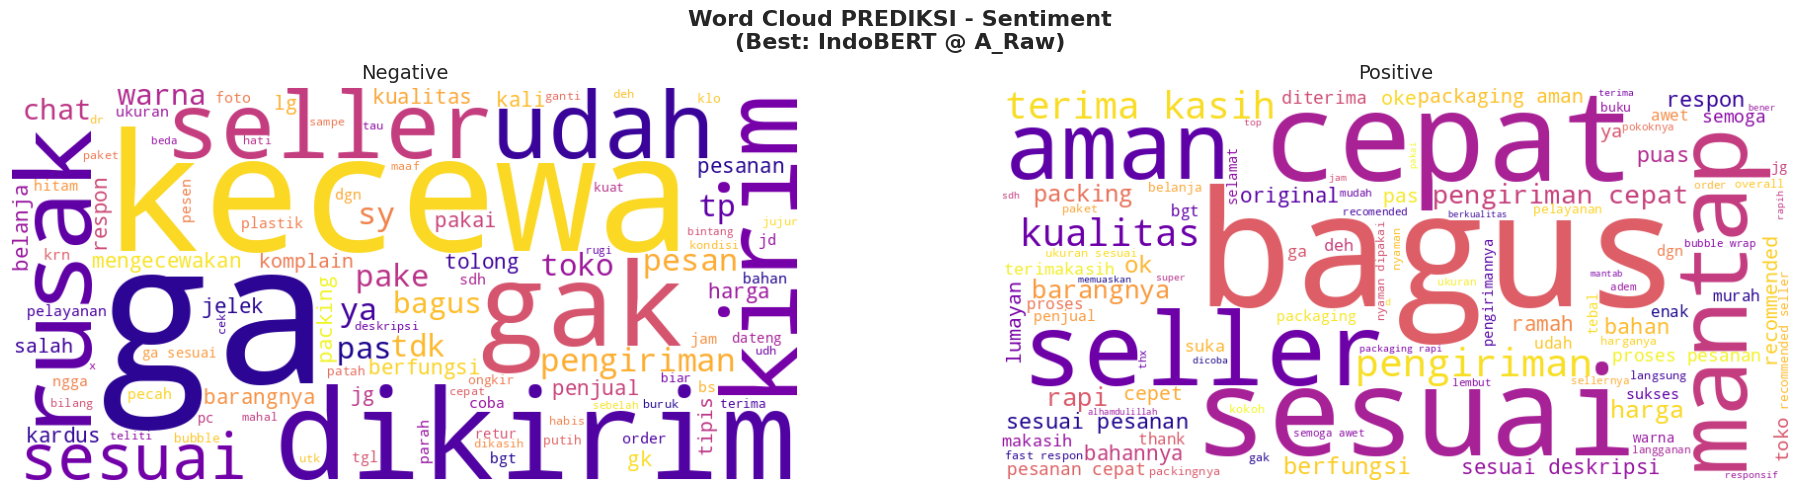

In [12]:
# ==========================================
# 1. WORD CLOUD HASIL PREDIKSI MODEL TERBAIK SKENARIO 2
# ==========================================
pip("wordcloud", "nltk")
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

nltk.download('stopwords', quiet=True)
indo_stopwords = set(stopwords.words('indonesian'))
custom_stopwords = {
    "yg", "nya", "di", "ke", "dari", "dan", "ini", "itu", "untuk", "dengan",
    "yang", "ada", "juga", "sudah", "buat", "karena", "kalo", "aku", "saya",
    "aja", "sama", "barang", "produk", "beli", "banget", "sih", "kok"
}
indo_stopwords = indo_stopwords.union(custom_stopwords)

print("\nMembuat Word Cloud berdasarkan hasil PREDIKSI Best Model Skenario 2...")

for task_name, (text_col, label_col, label_names) in TASKS.items():
    # FIX: Ganti s1 jadi s2
    best_dir = f"best_model_s2_{task_name}"

    if not os.path.exists(best_dir):
        print(f"Directory {best_dir} tidak ditemukan. Lewati task {task_name}.")
        continue

    texts = df[text_col].values
    labels = df[label_col].values
    _, _, test_texts, _, _, test_labels = make_splits(texts, labels)

    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer)
    trainer = Trainer(model=model)

    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    df_pred = pd.DataFrame({
        "text": test_texts,
        "pred_label": [label_names[p] for p in preds]
    })

    fig, axes = plt.subplots(1, len(label_names), figsize=(20, 5))
    # FIX: Judul menyesuaikan agar mencantumkan nama branch
    branch_name = BEST_MODEL_TRACKER[task_name]['branch']
    fig.suptitle(f"Word Cloud PREDIKSI - {task_name}\n(Best: {BEST_MODEL_TRACKER[task_name]['model_alias']} @ {branch_name})",
                 fontsize=16, fontweight='bold')

    if len(label_names) == 1:
        axes = [axes]

    for ax, cls in zip(axes, label_names):
        text_data = " ".join(df_pred[df_pred["pred_label"] == cls]["text"].tolist())

        if text_data.strip() == "":
            ax.set_title(f"{cls}\n(Tidak diprediksi)", fontsize=14, color='red')
            ax.axis("off")
            continue

        wc = WordCloud(width=800, height=400, background_color='white',
                       colormap='plasma', max_words=100,
                       stopwords=indo_stopwords).generate(text_data)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(cls, fontsize=14)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    del model, tokenizer, trainer, test_ds, df_pred
    free_memory()


Memproses Prediksi untuk Crosstab tiap Branch Augmentasi...
  ⚠️ Checkpoint A_Raw (Emotion) tidak ditemukan.
  ⚠️ Checkpoint A_Raw (Sentiment) tidak ditemukan.
  ⚠️ Checkpoint B_Oversample (Emotion) tidak ditemukan.
  ⚠️ Checkpoint B_Oversample (Sentiment) tidak ditemukan.
  ⚠️ Checkpoint C_BackTrans (Emotion) tidak ditemukan.
  ⚠️ Checkpoint C_BackTrans (Sentiment) tidak ditemukan.
  ⚠️ Checkpoint D_Synonym (Emotion) tidak ditemukan.
  ⚠️ Checkpoint D_Synonym (Sentiment) tidak ditemukan.


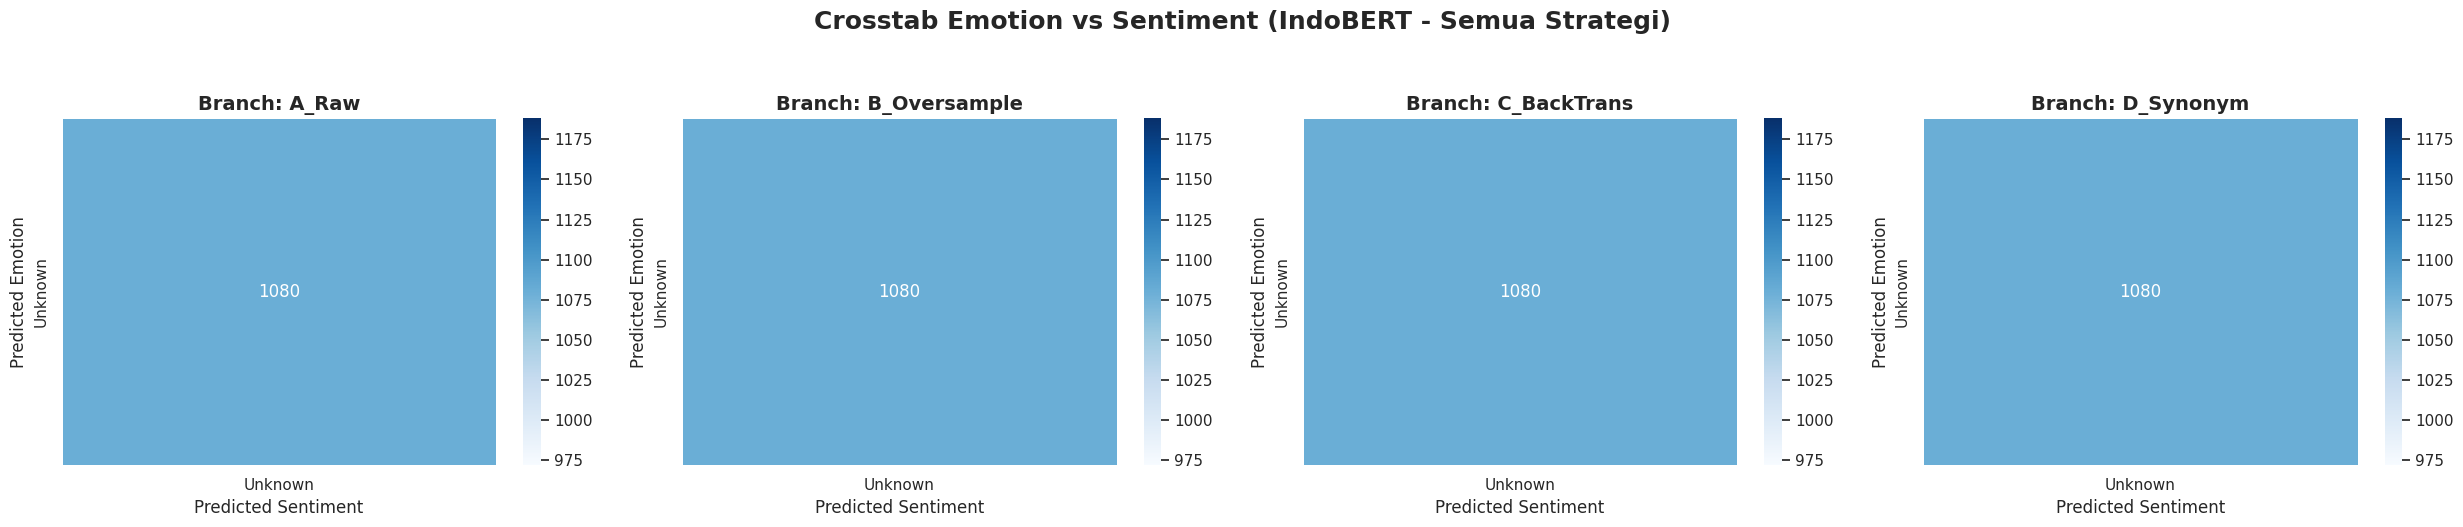

In [13]:
# ==========================================
# 4. CROSSTAB PREDIKSI PER STRATEGI AUGMENTASI
# ==========================================
import glob
import os

print("\nMemproses Prediksi untuk Crosstab tiap Branch Augmentasi...")

# Asumsi kita menggunakan model pertama di dict S2_MODELS (misal IndoBERT)
target_model_alias = list(S2_MODELS.keys())[0]
target_model_name = S2_MODELS[target_model_alias]
branches_list = ["A_Raw", "B_Oversample", "C_BackTrans", "D_Synonym"]

fig, axes = plt.subplots(1, len(branches_list), figsize=(25, 5))
fig.suptitle(f"Crosstab Emotion vs Sentiment ({target_model_alias} - Semua Strategi)",
             fontsize=18, fontweight='bold', y=1.05)

texts = df["text_clean"].values
labels_dummy = df["label_emotion"].values
_, _, test_texts, _, _, _ = make_splits(texts, labels_dummy)

for idx, branch_name in enumerate(branches_list):
    preds_dict = {}

    for task_name, (_, _, label_names) in TASKS.items():
        # FIX: Cari di folder Skenario 2 berdasarkan branch
        base_dir = f"s2_{task_name}_{branch_name}_{target_model_alias}"
        ckpts = glob.glob(f"{base_dir}/checkpoint-*")

        if not ckpts:
            print(f"  ⚠️ Checkpoint {branch_name} ({task_name}) tidak ditemukan.")
            preds_dict[task_name] = ["Unknown"] * len(test_texts)
            continue

        latest_ckpt = sorted(ckpts, key=lambda x: int(x.split('-')[-1]))[-1]

        tokenizer = AutoTokenizer.from_pretrained(target_model_name)
        model = AutoModelForSequenceClassification.from_pretrained(latest_ckpt).to(DEVICE)

        test_ds = build_hf_dataset(test_texts, [0]*len(test_texts), tokenizer)
        trainer = Trainer(model=model)

        preds_raw = trainer.predict(test_ds)
        preds_logits = preds_raw.predictions[0] if isinstance(preds_raw.predictions, tuple) else preds_raw.predictions
        preds_class = np.argmax(preds_logits, axis=-1)

        preds_dict[task_name] = [label_names[p] for p in preds_class]

        del model, tokenizer, trainer, test_ds
        free_memory()

    df_pred = pd.DataFrame({
        'Pred_Emotion': preds_dict.get('Emotion', ["Unknown"] * len(test_texts)),
        'Pred_Sentiment': preds_dict.get('Sentiment', ["Unknown"] * len(test_texts))
    })

    cross_tab = pd.crosstab(df_pred['Pred_Emotion'], df_pred['Pred_Sentiment'])

    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', linewidths=.5, ax=axes[idx])
    axes[idx].set_title(f"Branch: {branch_name}", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Predicted Sentiment")
    axes[idx].set_ylabel("Predicted Emotion")

plt.tight_layout()
plt.show()


Memuat model terbaik Skenario 2 dan membuat Confusion Matrix...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

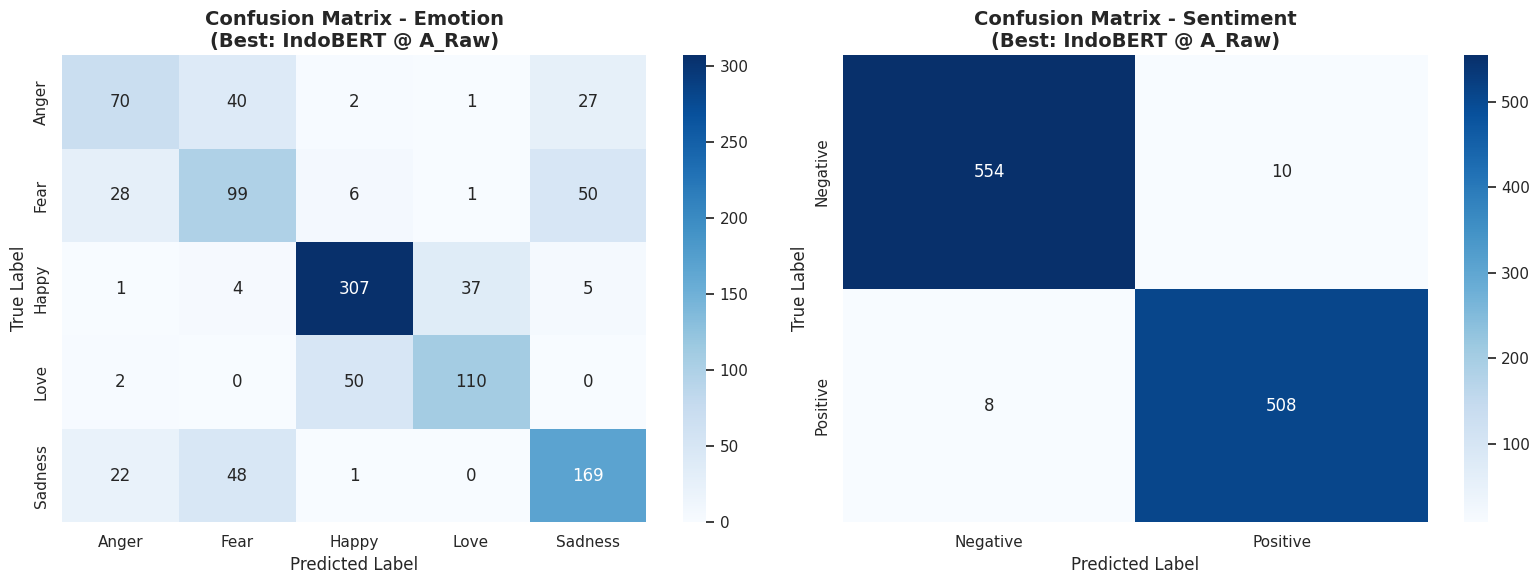

In [14]:
# ==========================================
# 3. CONFUSION MATRIX (Best Models Skenario 2)
# ==========================================
print("\nMemuat model terbaik Skenario 2 dan membuat Confusion Matrix...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (task_name, (text_col, label_col, label_names)) in enumerate(TASKS.items()):
    # FIX: Ganti s1 jadi s2
    best_dir = f"best_model_s2_{task_name}"

    if not os.path.exists(best_dir):
        print(f"Directory {best_dir} tidak ditemukan. Lewati task {task_name}.")
        continue

    texts = df[text_col].values
    labels = df[label_col].values
    _, _, test_texts, _, _, test_labels = make_splits(texts, labels)

    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer)
    trainer = Trainer(model=model)

    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[idx])

    branch_name = BEST_MODEL_TRACKER[task_name]['branch']
    axes[idx].set_title(f"Confusion Matrix - {task_name}\n(Best: {BEST_MODEL_TRACKER[task_name]['model_alias']} @ {branch_name})",
                        fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

    del model, tokenizer, trainer, test_ds
    free_memory()

plt.tight_layout()
plt.show()